In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

In [8]:
# read xls file
data = pd.read_excel('data/hydrology/wave_shapes.xls', index_col=0)

In [9]:
data

,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
0,0.224895,0.214304,0.224283,0.230353,0.219234,0.203512,0.191063,0.187472,0.224432,0.325306,...,0.487914,0.416368,0.352370,0.298759,0.265009,0.231677,0.219614,0.209021,0.199499,0.190946
1,0.273724,0.264464,0.258063,0.282115,0.334478,0.382453,0.404076,0.399115,0.399158,0.416695,...,0.640464,0.581705,0.517591,0.471392,0.431625,0.317330,0.298909,0.286502,0.281432,0.281160
2,0.142807,0.111245,0.092054,0.084458,0.083052,0.084611,0.089789,0.117994,0.218844,0.359502,...,0.405395,0.332713,0.283203,0.253713,0.243552,0.244920,0.251207,0.261964,0.272485,0.276548
3,0.322389,0.291245,0.265126,0.243159,0.226207,0.221248,0.243066,0.284168,0.366145,0.513192,...,0.581041,0.493294,0.410575,0.311241,0.273744,0.248766,0.231748,0.219752,0.211236,0.204669
4,0.415504,0.401833,0.382493,0.366031,0.353424,0.342985,0.329513,0.318997,0.323171,0.351816,...,0.382906,0.336599,0.359547,0.435538,0.518725,0.545424,0.535157,0.514660,0.501379,0.493753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,0.278171,0.379085,0.466318,0.510300,0.509764,0.480513,0.447139,0.429335,0.436611,0.471822,...,0.712708,0.692740,0.676736,0.651198,0.605623,0.540281,0.468399,0.407628,0.366517,0.339659
129,0.095764,0.093510,0.091621,0.089864,0.088082,0.086530,0.086463,0.092718,0.114886,0.163009,...,0.244569,0.215840,0.202656,0.196065,0.190216,0.183320,0.175660,0.167821,0.160192,0.153022
130,0.165290,0.176420,0.184651,0.188489,0.187010,0.182686,0.180664,0.184579,0.197674,0.223953,...,0.486583,0.410885,0.350216,0.306889,0.286772,0.291197,0.305676,0.310381,0.300843,0.286457
131,0.196609,0.183467,0.168779,0.158526,0.161475,0.186692,0.266764,0.381050,0.485387,0.596730,...,0.684559,0.625799,0.555326,0.476168,0.418644,0.372012,0.342295,0.325641,0.317453,0.313242


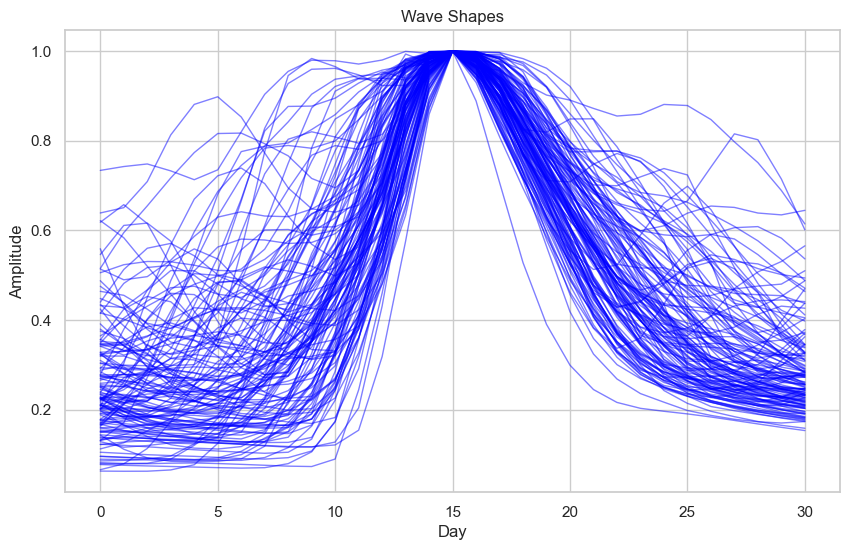

In [17]:
plt.figure(figsize=(10, 6))
for i in range(data.shape[0]):
    plt.plot(data.columns, data.iloc[i], color='blue', linewidth=1, alpha=0.5)
plt.title('Wave Shapes')
plt.xlabel('Day')
plt.ylabel('Amplitude')
plt.show()

In [2]:
# make sure pandas is version 1.0 or higher
# make sure networkx is verion 2.4 or higher
print(pd.__version__)
print(nx.__version__)

2.2.3
3.4.2


In [3]:
from ema_workbench import (
    Model,
    Policy,
    ema_logging,
    SequentialEvaluator,
    MultiprocessingEvaluator,
)
from dike_model_function import DikeNetwork  # @UnresolvedImport
from problem_formulation import get_model_for_problem_formulation, sum_over, sum_over_time



In [4]:
ema_logging.log_to_stderr(ema_logging.INFO)

# choose problem formulation number, between 0-5
# each problem formulation has its own list of outcomes
dike_model, planning_steps = get_model_for_problem_formulation(5)

problem_formulation_id : int {0, ..., 5}
problem formulations differ with respect to the objectives
- 0: Total cost, and casualties
- 1: Expected damages, costs, and casualties
- 2: expected damages, dike investment costs, rfr costs, evacuation cost, and casualties
- 3: costs and casualties disaggregated over dike rings, and room for the river and evacuation costs
- 4: Expected damages, dike investment cost and casualties disaggregated over dike rings and room for the river and evacuation costs
- 5: disaggregate over time and space


In [5]:
# enlisting uncertainties, their types (RealParameter/IntegerParameter/CategoricalParameter), lower boundary, and upper boundary
import copy

for unc in dike_model.uncertainties:
    print(repr(unc))

uncertainties = copy.deepcopy(dike_model.uncertainties)

CategoricalParameter('discount rate 0', [0, 1, 2, 3])
CategoricalParameter('discount rate 1', [0, 1, 2, 3])
CategoricalParameter('discount rate 2', [0, 1, 2, 3])
IntegerParameter('A.0_ID flood wave shape', 0, 132, resolution=None, default=None, variable_name=['A.0_ID flood wave shape'], pff=False)
RealParameter('A.1_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.1_Bmax'], pff=False)
RealParameter('A.1_pfail', 0, 1, resolution=None, default=None, variable_name=['A.1_pfail'], pff=False)
CategoricalParameter('A.1_Brate', [0, 1, 2])
RealParameter('A.2_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.2_Bmax'], pff=False)
RealParameter('A.2_pfail', 0, 1, resolution=None, default=None, variable_name=['A.2_pfail'], pff=False)
CategoricalParameter('A.2_Brate', [0, 1, 2])
RealParameter('A.3_Bmax', 30, 350, resolution=None, default=None, variable_name=['A.3_Bmax'], pff=False)
RealParameter('A.3_pfail', 0, 1, resolution=None, default=None, variable_name=['A.3_pfai

In [6]:
# enlisting policy levers, their types (RealParameter/IntegerParameter), lower boundary, and upper boundary
for policy in dike_model.levers:
    print(repr(policy))

levers = copy.deepcopy(dike_model.levers)

IntegerParameter('0_RfR 0', 0, 1, resolution=None, default=None, variable_name=['0_RfR 0'], pff=False)
IntegerParameter('0_RfR 1', 0, 1, resolution=None, default=None, variable_name=['0_RfR 1'], pff=False)
IntegerParameter('0_RfR 2', 0, 1, resolution=None, default=None, variable_name=['0_RfR 2'], pff=False)
IntegerParameter('1_RfR 0', 0, 1, resolution=None, default=None, variable_name=['1_RfR 0'], pff=False)
IntegerParameter('1_RfR 1', 0, 1, resolution=None, default=None, variable_name=['1_RfR 1'], pff=False)
IntegerParameter('1_RfR 2', 0, 1, resolution=None, default=None, variable_name=['1_RfR 2'], pff=False)
IntegerParameter('2_RfR 0', 0, 1, resolution=None, default=None, variable_name=['2_RfR 0'], pff=False)
IntegerParameter('2_RfR 1', 0, 1, resolution=None, default=None, variable_name=['2_RfR 1'], pff=False)
IntegerParameter('2_RfR 2', 0, 1, resolution=None, default=None, variable_name=['2_RfR 2'], pff=False)
IntegerParameter('3_RfR 0', 0, 1, resolution=None, default=None, variable

In [7]:
# enlisting outcomes
for outcome in dike_model.outcomes:
    print(repr(outcome))

ArrayOutcome('A.1_Expected Annual Damage')
ArrayOutcome('A.1_Dike Investment Costs')
ArrayOutcome('A.1_Expected Number of Deaths')
ArrayOutcome('A.2_Expected Annual Damage')
ArrayOutcome('A.2_Dike Investment Costs')
ArrayOutcome('A.2_Expected Number of Deaths')
ArrayOutcome('A.3_Expected Annual Damage')
ArrayOutcome('A.3_Dike Investment Costs')
ArrayOutcome('A.3_Expected Number of Deaths')
ArrayOutcome('A.4_Expected Annual Damage')
ArrayOutcome('A.4_Dike Investment Costs')
ArrayOutcome('A.4_Expected Number of Deaths')
ArrayOutcome('A.5_Expected Annual Damage')
ArrayOutcome('A.5_Dike Investment Costs')
ArrayOutcome('A.5_Expected Number of Deaths')
ArrayOutcome('RfR Total Costs')
ArrayOutcome('Expected Evacuation Costs')


In [8]:
# running the model through EMA workbench
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(scenarios=50, policies=4)

[MainProcess/INFO] pool started with 8 workers
[MainProcess/INFO] performing 50 scenarios * 4 policies * 1 model(s) = 200 experiments
100%|████████████████████████████████████████| 200/200 [00:28<00:00,  6.99it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


In [9]:
# observing the simulation runs
experiments, outcomes = results
print(outcomes.keys())
experiments

dict_keys(['A.1 Total Costs', 'A.1_Expected Number of Deaths', 'A.2 Total Costs', 'A.2_Expected Number of Deaths', 'A.3 Total Costs', 'A.3_Expected Number of Deaths', 'A.4 Total Costs', 'A.4_Expected Number of Deaths', 'A.5 Total Costs', 'A.5_Expected Number of Deaths', 'RfR Total Costs', 'Expected Evacuation Costs'])


,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,EWS_DaysToThreat,scenario,policy,model
0,8,303.736336,1.5,0.462428,263.051190,1.5,0.257435,184.682919,1.5,0.041140,...,4,2,8,1,2,8,4,4,0,dikesnet
1,58,342.505421,10.0,0.842481,245.702642,1.5,0.390185,98.856045,1.5,0.945891,...,4,2,8,1,2,8,4,5,0,dikesnet
2,7,136.235963,10.0,0.647498,235.194030,10.0,0.661143,219.311145,1.5,0.859647,...,4,2,8,1,2,8,4,6,0,dikesnet
3,31,38.379789,1.5,0.368517,341.221160,1.0,0.175196,109.402404,1.0,0.761349,...,4,2,8,1,2,8,4,7,0,dikesnet
4,15,335.341222,1.5,0.613187,281.479942,10.0,0.549214,33.828302,1.0,0.994556,...,4,2,8,1,2,8,4,8,0,dikesnet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,61,147.447571,10.0,0.097054,230.509309,1.0,0.215229,66.104417,1.0,0.559180,...,5,7,0,9,5,8,3,49,3,dikesnet
196,44,48.431141,10.0,0.076120,256.233659,1.0,0.704788,338.874138,1.0,0.133447,...,5,7,0,9,5,8,3,50,3,dikesnet
197,91,112.378240,1.0,0.490170,153.916065,10.0,0.729641,191.889859,1.0,0.628640,...,5,7,0,9,5,8,3,51,3,dikesnet
198,4,156.048585,1.0,0.878355,327.288790,1.5,0.002671,253.624594,1.5,0.474304,...,5,7,0,9,5,8,3,52,3,dikesnet


In [9]:
# observing the simulation runs
experiments, outcomes = results
print(outcomes.keys())
experiments

dict_keys(['A.1_Expected Annual Damage', 'A.1_Dike Investment Costs', 'A.1_Expected Number of Deaths', 'A.2_Expected Annual Damage', 'A.2_Dike Investment Costs', 'A.2_Expected Number of Deaths', 'A.3_Expected Annual Damage', 'A.3_Dike Investment Costs', 'A.3_Expected Number of Deaths', 'A.4_Expected Annual Damage', 'A.4_Dike Investment Costs', 'A.4_Expected Number of Deaths', 'A.5_Expected Annual Damage', 'A.5_Dike Investment Costs', 'A.5_Expected Number of Deaths', 'RfR Total Costs', 'Expected Evacuation Costs'])


,A.0_ID flood wave shape,A.1_Bmax,A.1_Brate,A.1_pfail,A.2_Bmax,A.2_Brate,A.2_pfail,A.3_Bmax,A.3_Brate,A.3_pfail,...,A.4_DikeIncrease 0,A.4_DikeIncrease 1,A.4_DikeIncrease 2,A.5_DikeIncrease 0,A.5_DikeIncrease 1,A.5_DikeIncrease 2,EWS_DaysToThreat,scenario,policy,model
0,56,105.395979,10.0,0.365850,295.504957,1.5,0.000391,132.381959,1.5,0.581077,...,0,5,2,0,1,8,4,4,0,dikesnet
1,75,316.636844,1.5,0.645635,203.375118,1.0,0.740285,49.040597,10.0,0.926243,...,0,5,2,0,1,8,4,5,0,dikesnet
2,104,37.834336,1.5,0.020641,94.056101,10.0,0.307232,73.589662,1.0,0.503053,...,0,5,2,0,1,8,4,6,0,dikesnet
3,72,140.523453,1.0,0.858418,239.043972,1.0,0.511049,284.961760,1.0,0.344783,...,0,5,2,0,1,8,4,7,0,dikesnet
4,65,172.476535,1.0,0.630978,61.113886,1.0,0.196409,304.281274,1.5,0.474296,...,0,5,2,0,1,8,4,8,0,dikesnet
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,78,272.776679,1.5,0.424778,45.686226,10.0,0.562965,311.852908,1.5,0.405838,...,3,10,8,9,9,7,0,49,3,dikesnet
196,84,150.607183,1.5,0.139669,229.538068,10.0,0.337790,228.326805,1.5,0.951769,...,3,10,8,9,9,7,0,50,3,dikesnet
197,67,167.822488,1.5,0.252713,291.816464,1.0,0.556025,214.293129,10.0,0.771352,...,3,10,8,9,9,7,0,51,3,dikesnet
198,49,257.301218,10.0,0.686854,202.337955,10.0,0.684805,342.540037,1.5,0.375264,...,3,10,8,9,9,7,0,52,3,dikesnet


In [10]:
outcomes

{'A.1_Expected Annual Damage': array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0

In [10]:
# only works because we have scalar outcomes
pd.DataFrame(outcomes)

,A.1 Total Costs,A.1_Expected Number of Deaths,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
0,1.257972e+08,0.000000,2.049618e+08,0.000000,1.221445e+08,0.0,4.310139e+07,0.000246,2.396077e+08,0.011351,1.245700e+09,8317.344842
1,1.257972e+08,0.000000,2.049618e+08,0.000000,1.221445e+08,0.0,3.778898e+07,0.000000,1.593055e+08,0.004760,1.245700e+09,3182.944565
2,1.257972e+08,0.000000,2.049618e+08,0.000000,1.221445e+08,0.0,3.778898e+07,0.000000,1.186665e+08,0.001894,1.245700e+09,1252.996043
3,1.257972e+08,0.000000,2.049618e+08,0.000000,1.221445e+08,0.0,3.778898e+07,0.000000,1.117376e+08,0.000382,1.245700e+09,249.442287
4,1.257972e+08,0.000000,2.049618e+08,0.000000,1.221445e+08,0.0,3.778898e+07,0.000000,2.383698e+08,0.016112,1.245700e+09,11516.793241
...,...,...,...,...,...,...,...,...,...,...,...,...
195,1.434961e+08,0.000068,1.590092e+08,0.000000,1.075742e+08,0.0,2.793940e+07,0.000000,1.803140e+08,0.000000,5.233000e+08,8.744198
196,1.503345e+08,0.000468,1.590092e+08,0.000000,1.075742e+08,0.0,2.793940e+07,0.000000,1.803140e+08,0.000000,5.233000e+08,64.331669
197,1.423478e+08,0.000000,1.590092e+08,0.000000,1.075742e+08,0.0,2.793940e+07,0.000000,1.803140e+08,0.000000,5.233000e+08,0.000000
198,1.423478e+08,0.000000,1.746693e+08,0.002073,1.075742e+08,0.0,2.793940e+07,0.000000,1.803140e+08,0.000000,5.233000e+08,1004.953190


In [11]:
# defining specific policies
# for example, policy 1 is about extra protection in upper boundary
# policy 2 is about extra protection in lower boundary
# policy 3 is extra protection in random locations


def get_do_nothing_dict():
    return {l.name: 0 for l in dike_model.levers}


policies = [
    Policy(
        "policy 1",
        **dict(
            get_do_nothing_dict(),
            **{"0_RfR 0": 1, "0_RfR 1": 1, "0_RfR 2": 1, "A.1_DikeIncrease 0": 5}
        )
    ),
    Policy(
        "policy 2",
        **dict(
            get_do_nothing_dict(),
            **{"4_RfR 0": 1, "4_RfR 1": 1, "4_RfR 2": 1, "A.5_DikeIncrease 0": 5}
        )
    ),
    Policy(
        "policy 3",
        **dict(
            get_do_nothing_dict(),
            **{"1_RfR 0": 1, "2_RfR 1": 1, "3_RfR 2": 1, "A.3_DikeIncrease 0": 5}
        )
    ),
]

In [12]:
# pass the policies list to EMA workbench experiment runs
n_scenarios = 100
with MultiprocessingEvaluator(dike_model) as evaluator:
    results = evaluator.perform_experiments(n_scenarios, policies)

[MainProcess/INFO] pool started with 8 workers
[MainProcess/INFO] performing 100 scenarios * 3 policies * 1 model(s) = 300 experiments
100%|████████████████████████████████████████| 300/300 [00:39<00:00,  7.67it/s]
[MainProcess/INFO] experiments finished
[MainProcess/INFO] terminating pool


In [13]:
experiments, outcomes = results

In [14]:
# only works because we have scalar outcomes
pd.DataFrame(outcomes)

,A.1 Total Costs,A.1_Expected Number of Deaths,A.2 Total Costs,A.2_Expected Number of Deaths,A.3 Total Costs,A.3_Expected Number of Deaths,A.4 Total Costs,A.4_Expected Number of Deaths,A.5 Total Costs,A.5_Expected Number of Deaths,RfR Total Costs,Expected Evacuation Costs
0,5.397251e+07,0.000000,4.366263e+07,0.054014,1.413471e+07,0.033292,4.411055e+07,0.026591,0.000000e+00,0.000000,253800000.0,0.0
1,5.397251e+07,0.000000,1.280981e+07,0.013943,8.508806e+07,0.170242,1.217585e+08,0.059320,0.000000e+00,0.000000,253800000.0,0.0
2,5.397251e+07,0.000000,3.150719e+08,0.214732,1.392252e+09,1.780615,0.000000e+00,0.000000,0.000000e+00,0.000000,253800000.0,0.0
3,5.397251e+07,0.000000,2.943777e+07,0.021612,3.831493e+07,0.052540,1.449036e+07,0.005824,4.128615e+07,0.028508,253800000.0,0.0
4,5.397251e+07,0.000000,1.109401e+07,0.010844,1.311998e+09,2.213963,0.000000e+00,0.000000,0.000000e+00,0.000000,253800000.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
295,6.351978e+07,0.048607,0.000000e+00,0.000000,2.879840e+07,0.000000,5.929795e+06,0.003429,7.420002e+07,0.078933,369700000.0,0.0
296,1.364020e+09,0.964262,0.000000e+00,0.000000,2.879840e+07,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,369700000.0,0.0
297,8.872427e+08,0.776978,6.302400e+07,0.075995,2.879840e+07,0.000000,5.499078e+06,0.003207,0.000000e+00,0.000000,369700000.0,0.0
298,0.000000e+00,0.000000,3.453505e+07,0.040002,2.879840e+07,0.000000,4.431426e+07,0.024772,0.000000e+00,0.000000,369700000.0,0.0
